Regina Tamayo León

26 de marzo 2026

## **Actividad Heart Prediction** ##

In [8]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


**EDA**

In [37]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
df=pd.read_csv("Heart Prediction Quantum Dataset.csv")
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [20]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


Edad int años[30,79]
Género categórico {0,1}
presión sanguínea sistólica (<80,hipertenso)
ritmo cardiaco reposo
enfermedad bool

<Axes: ylabel='Frequency'>

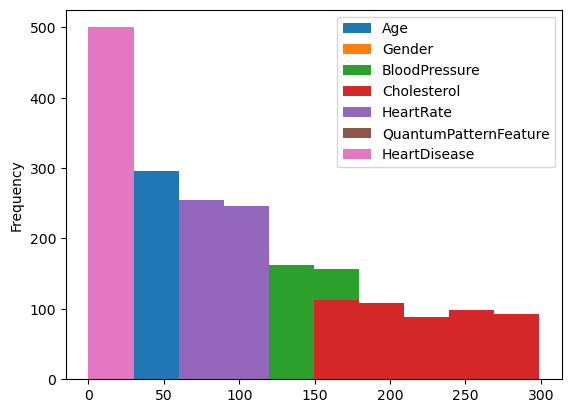

In [21]:
df.plot.hist()

**Histogramas**

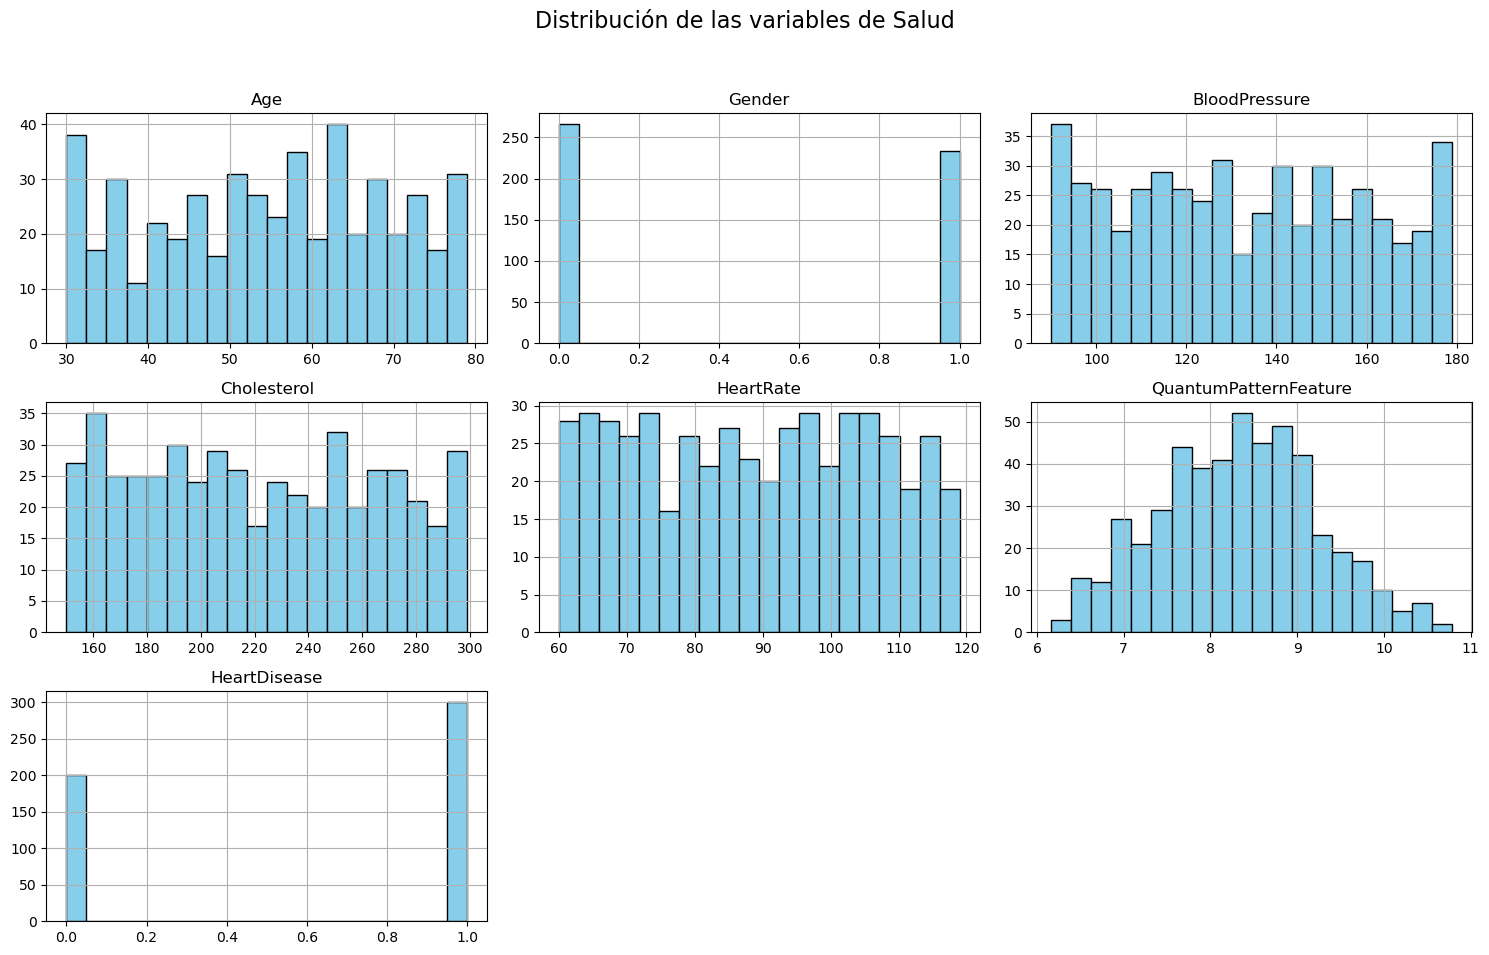

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
df.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribución de las variables de Salud", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Variables categóricas y numéricas**

In [44]:
num_cols=["Age","BloodPressure","Cholesterol","HeartRate"]
cat_cols=["Gender"]
target_col=["HeartDisease"]

In [45]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
X=df[num_cols+cat_cols]
y=df[target_col]

In [46]:
num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

In [47]:
model =MLPClassifier(hidden_layer_sizes=(5,10),random_state=42)

In [48]:
preprocessor=ColumnTransformer(
    transformers=[('num',num_transformer,num_cols),
                  ('cat',cat_transformer,cat_cols)
                 ]
)

In [49]:
pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',model)]
                 )

In [50]:
pipeline.fit(X,y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Gender'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [51]:
pipeline.score(X,y)

0.78

El puntaje obtenido de 0.78  demuestra que el modelo tiene una capacidad predictiva confiable. En el contexto clínico, este valor indica que la combinación de variables como la edad, el colesterol y la presión arterial permite identificar patrones de riesgo significativos, aunque todavía existe un margen de error que podría atribuirse a factores no capturados en el dataset actual.

*Segunda capa:10 neuronas*

In [58]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)


Escalamiento y modelo

In [59]:
Pipeline_auc = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', probability=True)) # Usando el kernel lineal que mencionaste
])

Validación cruzada y resultado

In [60]:
scores_auc = cross_val_score(Pipeline_auc, X, y, cv=10, scoring='roc_auc')

print(f"AUC promedio (10-Folds): {np.mean(scores_auc):.4f}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

AUC promedio (10-Folds): 0.8022


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

Permite que el modelo capture relaciones no lineales en los datos, aumentando su capacidad de aprendizaje

**¿cual es la mejor capa: [2,6],[5,15],[3,16]?**

In [65]:
architectures = {
    "Capa [2, 6]": (2, 6),
    "Capa [5, 15]": (5, 15),
    "Capa [3, 16]": (3, 16)
}


kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"{'Arquitectura':<15} | {'AUC-ROC Promedio':<18} | {'Desviación'}")

for nombre, capas in architectures.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=capas, max_iter=1000, random_state=42))
    ])
    
    
    scores = cross_val_score(pipe, X, y, cv=kf, scoring='roc_auc')
    
    print(f"{nombre:<15} | {np.mean(scores):.4f}  | {np.std(scores):.4f}")

Arquitectura    | AUC-ROC Promedio   | Desviación


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vecto

Capa [2, 6]     | 0.8191  | 0.0944


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vecto

Capa [5, 15]    | 0.8668  | 0.0746


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vecto

Capa [3, 16]    | 0.8363  | 0.0727


la configuración [5, 15] presenta el mejor desempeño con un AUC-ROC de 0.8668. Este valor indica una alta capacidad predictiva y superioridad frente a la arquitectura [3, 16] (0.8363). Se observa que tener una primera capa ligeramente más robusta (5 neuronas) permite una mejor extracción de características de las variables clínicas y demográficas del dataset, resultando en un modelo más preciso para la detección de tumores malignos.